In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K

In [2]:
num_classes = 10

In [3]:
batch_size = 64
epochs = 24

In [4]:
img_rows, img_cols = 28,28

In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
 X_test.shape

(10000, 28, 28)

In [8]:
X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

In [9]:
input_shape

(28, 28, 1)

In [10]:
X_train.shape

(60000, 28, 28, 1)

In [11]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
X_train/=255.
X_test/=255.
print('X_train shape: ', X_train.shape)
print("X_test shape: ", X_test.shape)
print(y_train[0:3])

X_train shape:  (60000, 28, 28, 1)
X_test shape:  (10000, 28, 28, 1)
[9 0 0]


In [12]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train[0:2])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [13]:
model = Sequential()

In [14]:
model.add(Conv2D(32, kernel_size=(3,3), activation="relu", input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss="categorical_crossentropy",
             optimizer="adam",
             metrics=["accuracy"])

In [16]:
hist = model.fit(X_train, y_train, 
                 batch_size=64,
                 epochs = 24,
                 verbose=1,
                 validation_data=(X_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8021 - loss: 0.5415 - val_accuracy: 0.8549 - val_loss: 0.4006
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.8716 - loss: 0.3525 - val_accuracy: 0.8727 - val_loss: 0.3609
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8885 - loss: 0.3055 - val_accuracy: 0.8812 - val_loss: 0.3181
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.9003 - loss: 0.2732 - val_accuracy: 0.8874 - val_loss: 0.3043
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9088 - loss: 0.2485 - val_accuracy: 0.8962 - val_loss: 0.2877
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.9140 - loss: 0.2310 - val_accuracy: 0.9058 - val_loss: 0.2686
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9211 - loss: 0.2121 - val_accuracy: 0.9041 - val_loss: 0.2644
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.9271 - loss: 0.1968 - 

Test Loss:  0.40550172328948975
Test accuracy:  0.9090999960899353


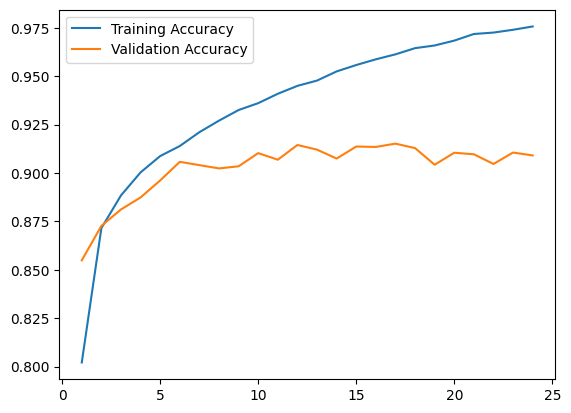

In [17]:
score = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss: ",score[0])
print("Test accuracy: ",score[1])

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
epoch_list = list(range(1,len(hist.history['accuracy'])+1))
plt.plot(epoch_list, hist.history['accuracy'], epoch_list, hist.history['val_accuracy'])
plt.legend(("Training Accuracy","Validation Accuracy"))
plt.show()

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)